In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 

np.random.seed(42)

a = 1
b = -2
c = 3
d = 5
e = -1
f = 4

X = np.linspace(-3,3,50).reshape(-1,1)

noise = np.random.normal(0,5, size = (50,))
 # polynomial degree used 4, because the data is generated using a cubic polynomial function 

y = a*(X[:,0] **4 ) + b*(X[:,0] **3 ) + c*(X[:,0] **2) + d*(X[:,0]) + noise # d is intercept  



Degree / Train R^2 / Test R^2
----------------------------------------
1 / 0.1830 / -1.6590
3 / 0.9557 / 0.8601
10 / 0.9879 / 0.9615
30 / 0.9927 / 0.0919


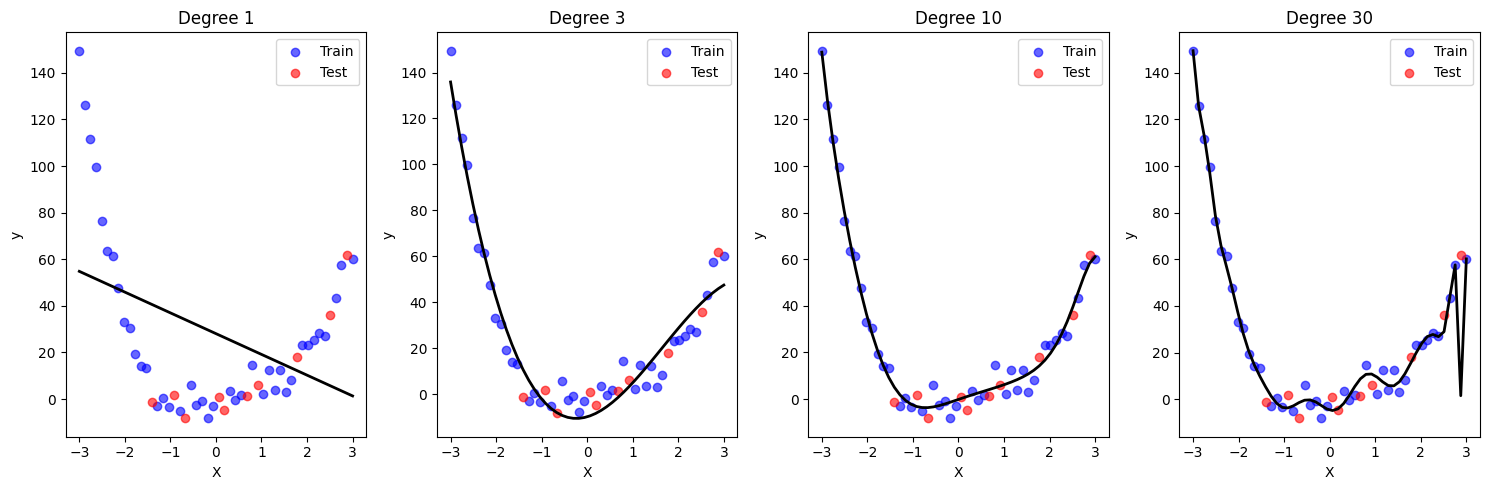

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, 
    random_state = 42) # random_state helps in keeping consistent splits across runs 
 
degrees = [1,3,10,30]

plt.figure(figsize=(15,5))

print("Degree / Train R^2 / Test R^2")
print("-" * 40)

for i , degree in enumerate(degrees):

    model = make_pipeline(
        PolynomialFeatures(degree),
        StandardScaler(),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    print(f"{degree} / {train_r2:.4f} / {test_r2:.4f}")

    X_plot = np.linspace(-3,3,50).reshape(-1,1)
    y_plot = model.predict(X_plot)

    plt.subplot(1,4,i+1)
    plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Train')
    plt.scatter(X_test, y_test, color='red', alpha=0.6, label='Test')
    plt.plot(X_plot, y_plot, color='black', linewidth=2)
    plt.title(f"Degree {degree}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()

    


As the polynomial degree increases, the model becomes more flexible. A degree-1 polynomial is too simple and underfits the cubic data. A degree-3 polynomial matches the true underlying function well and achieves a good balance between training and testing performance. A degree-10 polynomial is more flexible but still generalizes well because there is enough data. A degree-30 polynomial becomes overly complex, introducing unnecessary oscillations—especially near the boundaries—to fit the noise in the training data. This leads to excellent training performance but poor generalization on unseen test data, demonstrating overfitting.